In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

# Kết nối Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Cấu hình hiển thị biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Đường dẫn tới tệp dữ liệu (Cập nhật lại theo cấu trúc Drive của bạn)
path_to_ungraph = '/content/drive/MyDrive/MXH/com-amazon.ungraph.txt'
path_to_cmty = '/content/drive/MyDrive/MXH/com-amazon.all.dedup.cmty.txt'

print("Đang tải dữ liệu cạnh (edges)...")
edges_df = pd.read_csv(path_to_ungraph, sep='\t', comment='#', names=['source', 'target'])

print("Đang xây dựng đồ thị NetworkX...")
G = nx.from_pandas_edgelist(edges_df, 'source', 'target')

print(f"Số lượng Node (Sản phẩm): {G.number_of_nodes():,}")
print(f"Số lượng Edge (Liên kết co-purchasing): {G.number_of_edges():,}")

Đang tải dữ liệu cạnh (edges)...
Đang xây dựng đồ thị NetworkX...
Số lượng Node (Sản phẩm): 334,863
Số lượng Edge (Liên kết co-purchasing): 925,872


In [8]:
print("Đang tìm Largest Connected Component (LCC)...")
# Trích xuất các thành phần liên thông và lấy thành phần lớn nhất
connected_components = list(nx.connected_components(G))
lcc_nodes = max(connected_components, key=len)
LCC = G.subgraph(lcc_nodes).copy()

print("\n--- THỐNG KÊ LCC ---")
print(f"Số nodes trong LCC: {LCC.number_of_nodes():,} ({LCC.number_of_nodes()/G.number_of_nodes()*100:.2f}% tổng mạng)")
print(f"Số edges trong LCC: {LCC.number_of_edges():,}")
print(f"Density (Mật độ LCC): {nx.density(LCC):.6f}")
#print(f"Average Clustering Coefficient: {nx.average_clustering(LCC):.4f}")

Đang tìm Largest Connected Component (LCC)...

--- THỐNG KÊ LCC ---
Số nodes trong LCC: 334,863 (100.00% tổng mạng)
Số edges trong LCC: 925,872
Density (Mật độ LCC): 0.000017



--- THỐNG KÊ BẬC (DEGREE) ---
Bậc lớn nhất (Max Degree): 549
Bậc nhỏ nhất (Min Degree): 1
Bậc trung bình: 5.53
Trung vị bậc (Median Degree): 4.0


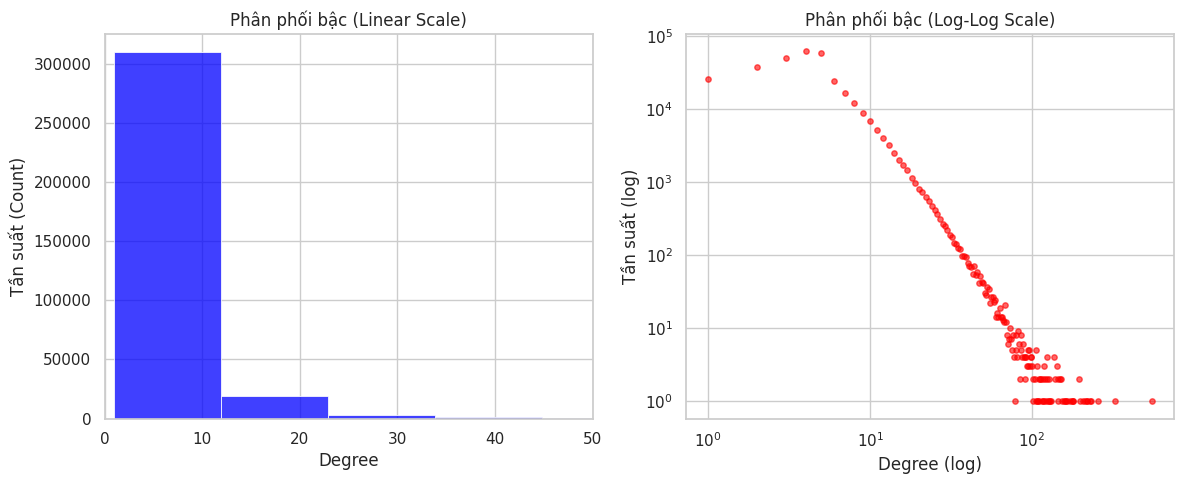

In [13]:
# Lấy danh sách bậc của tất cả các node trong LCC
degrees = [deg for node, deg in LCC.degree()]

# Thống kê mô tả về Bậc
print("\n--- THỐNG KÊ BẬC (DEGREE) ---")
print(f"Bậc lớn nhất (Max Degree): {max(degrees)}")
print(f"Bậc nhỏ nhất (Min Degree): {min(degrees)}")
print(f"Bậc trung bình: {np.mean(degrees):.2f}")
print(f"Trung vị bậc (Median Degree): {np.median(degrees)}")

# Vẽ biểu đồ phân phối bậc (Scale tuyến tính)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(degrees, bins=50, kde=False, color='blue')
plt.xlim(0, 50)
plt.title("Phân phối bậc (Linear Scale)")
plt.xlabel("Degree")
plt.ylabel("Tần suất (Count)")

# Vẽ biểu đồ phân phối bậc (Log-Log Scale để kiểm tra Power-law)
plt.subplot(1, 2, 2)
degree_counts = pd.Series(degrees).value_counts().sort_index()
plt.scatter(degree_counts.index, degree_counts.values, alpha=0.6, color='red', s=15)
plt.xscale('log')
plt.yscale('log')
plt.title("Phân phối bậc (Log-Log Scale)")
plt.xlabel("Degree (log)")
plt.ylabel("Tần suất (log)")

plt.tight_layout()
plt.show()

Đang đọc tệp Ground Truth Communities...
Tổng số communities ground truth: 75,149
Kích thước cụm lớn nhất: 53,551
Kích thước cụm nhỏ nhất: 3
Kích thước cụm trung bình: 30.23


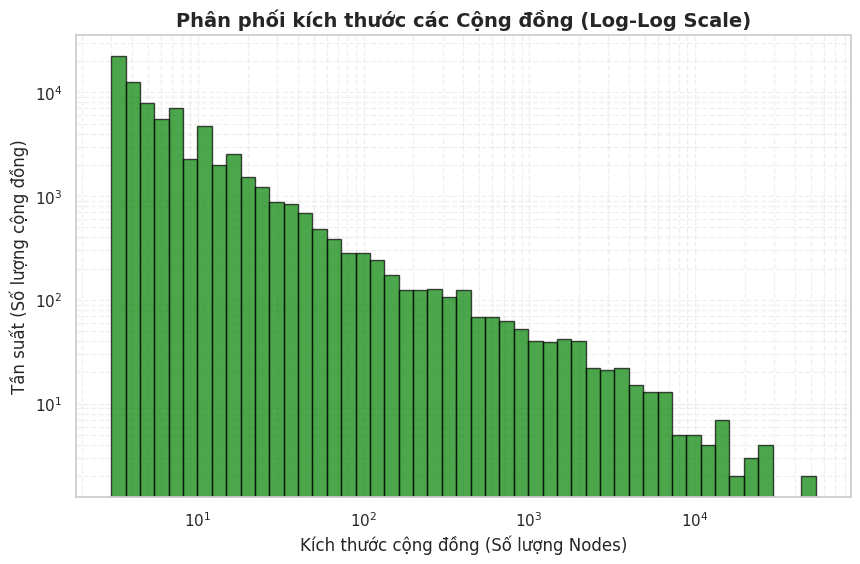

In [11]:
print("Đang đọc tệp Ground Truth Communities...")
communities = []
with open(path_to_cmty, 'r') as f:
    for line in f:
        # Bỏ qua comments nếu có
        if line.startswith('#'): continue
        # Mỗi dòng là một community chứa các node id cách nhau bằng khoảng trắng
        cmty_nodes = [int(x) for x in line.strip().split()]
        communities.append(cmty_nodes)

print(f"Tổng số communities ground truth: {len(communities):,}")

# Tính kích thước (số nodes) của mỗi community
cmty_sizes = [len(c) for c in communities]

print(f"Kích thước cụm lớn nhất: {max(cmty_sizes):,}")
print(f"Kích thước cụm nhỏ nhất: {min(cmty_sizes):,}")
print(f"Kích thước cụm trung bình: {np.mean(cmty_sizes):.2f}")

# Vẽ phân phối kích thước cộng đồng
plt.figure(figsize=(10, 6))

# 1. Tự tạo 50 khoảng chia (bins) theo thang đo logarit
min_size = min(cmty_sizes)
max_size = max(cmty_sizes)
log_bins = np.logspace(np.log10(min_size), np.log10(max_size), 50)

# 2. Vẽ histogram bằng matplotlib với bins vừa tạo
plt.hist(cmty_sizes, bins=log_bins, color='green', edgecolor='black', alpha=0.7)

# 3. Chuyển cả 2 trục sang thang log
plt.xscale('log')
plt.yscale('log')

plt.title("Phân phối kích thước các Cộng đồng (Log-Log Scale)", fontsize=14, fontweight='bold')
plt.xlabel("Kích thước cộng đồng (Số lượng Nodes)", fontsize=12)
plt.ylabel("Tần suất (Số lượng cộng đồng)", fontsize=12)

# Thêm lưới cho dễ nhìn
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.show()

Degree Assortativity Coefficient: -0.0588
Estimated Average Clustering Coefficient (trên 5000 nodes): 0.3980
Sản phẩm 'hot' nhất là Node 548091 với 549 kết nối.


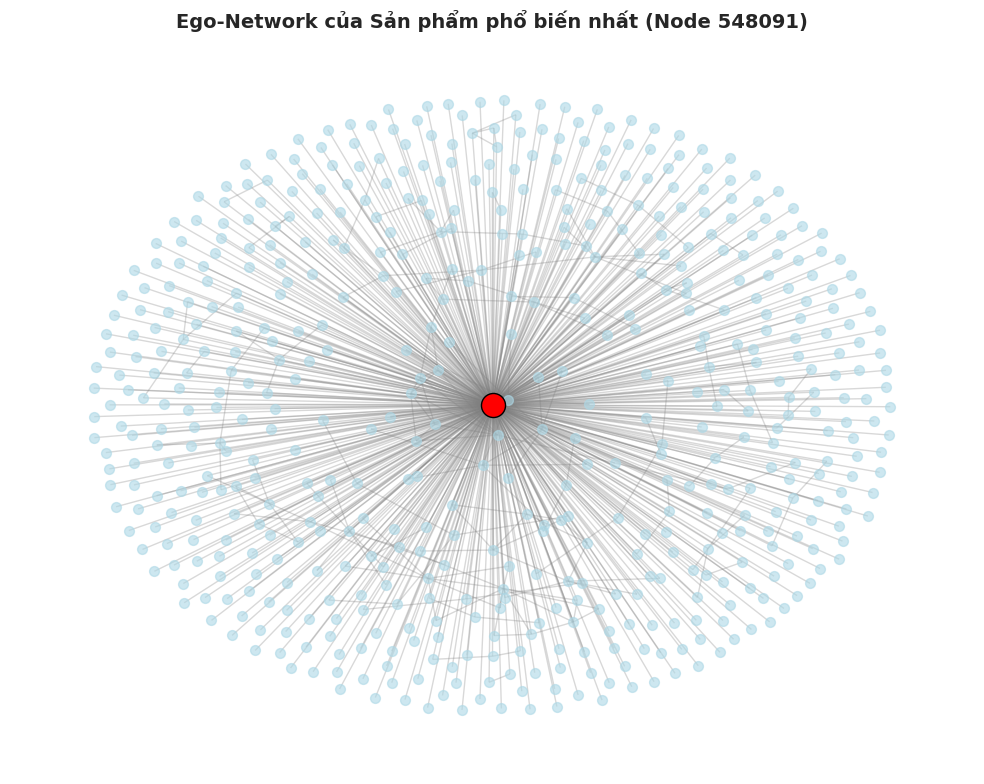

In [17]:

assortativity = nx.degree_assortativity_coefficient(LCC)
print(f"Degree Assortativity Coefficient: {assortativity:.4f}")

sample_size = 5000
sampled_nodes = random.sample(list(LCC.nodes()), sample_size)

local_clustering_sampled = nx.clustering(LCC, nodes=sampled_nodes)
avg_clustering_estimated = sum(local_clustering_sampled.values()) / sample_size

print(f"Estimated Average Clustering Coefficient (trên {sample_size} nodes): {avg_clustering_estimated:.4f}")

top_node, max_deg = max(dict(LCC.degree()).items(), key=lambda x: x[1])
print(f"Sản phẩm 'hot' nhất là Node {top_node} với {max_deg} kết nối.")

ego_net = nx.ego_graph(LCC, top_node, radius=1)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(ego_net, seed=42)

nx.draw_networkx_nodes(ego_net, pos,
                       nodelist=[n for n in ego_net.nodes() if n != top_node],
                       node_color='lightblue',
                       node_size=50,
                       alpha=0.6)

nx.draw_networkx_nodes(ego_net, pos,
                       nodelist=[top_node],
                       node_color='red',
                       node_size=300,
                       edgecolors='black')

nx.draw_networkx_edges(ego_net, pos, alpha=0.3, edge_color='gray')

plt.title(f"Ego-Network của Sản phẩm phổ biến nhất (Node {top_node})", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

--- 1. PHÂN TÍCH K-CORE (TÌM LÕI MẠNG LƯỚI) ---
Max K-Core của mạng lưới là: 6


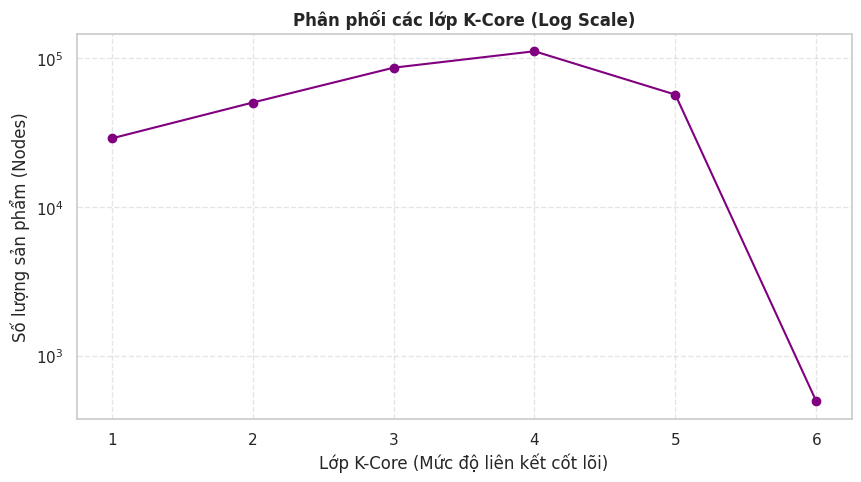


--- 2. PHÂN TÍCH CÁC MẢNH VỠ (ISOLATED COMPONENTS) ---
Toàn bộ mạng lưới là một khối liên thông duy nhất (Không có mảnh vỡ).

--- 3. HIỆU ỨNG THẾ GIỚI NHỎ (AVERAGE PATH LENGTH) ---
Đang đo lường khoảng cách cho 1000 cặp sản phẩm ngẫu nhiên...
Khoảng cách trung bình: 11.85 'bước nhảy'
Khoảng cách xa nhất đo được (Đường kính mẫu): 27 'bước nhảy'


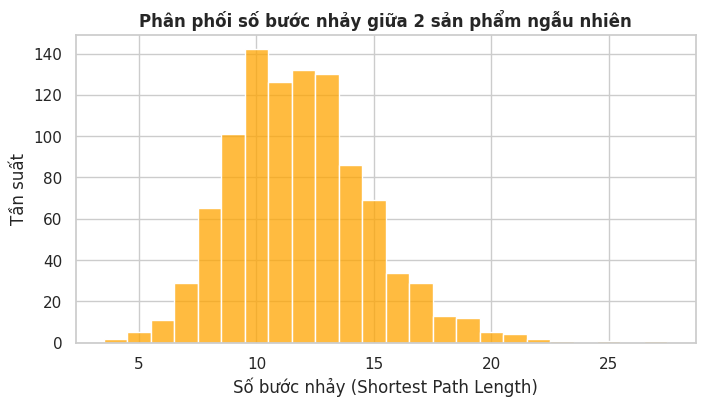

In [16]:
core_numbers = nx.core_number(LCC)
max_core = max(core_numbers.values())
print(f"Max K-Core của mạng lưới là: {max_core}")

core_counts = pd.Series(core_numbers.values()).value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(core_counts.index, core_counts.values, marker='o', color='purple')
plt.yscale('log')
plt.title("Phân phối các lớp K-Core (Log Scale)", fontweight='bold')
plt.xlabel("Lớp K-Core (Mức độ liên kết cốt lõi)")
plt.ylabel("Số lượng sản phẩm (Nodes)")
plt.grid(True, ls="--", alpha=0.5)
plt.show()

core_nodes_count = core_counts[max_core]

comp_sizes = [len(c) for c in nx.connected_components(G)]
comp_sizes_no_lcc = [size for size in comp_sizes if size != LCC.number_of_nodes()]

if comp_sizes_no_lcc:
    print(f"Tổng số mảnh vỡ nằm ngoài LCC: {len(comp_sizes_no_lcc):,} mảnh.")
    print(f"Mảnh vỡ lớn thứ 2 chỉ có kích thước: {max(comp_sizes_no_lcc)} nodes.")
else:
    print("Toàn bộ mạng lưới là một khối liên thông duy nhất (Không có mảnh vỡ).")


sample_pairs = 1000
path_lengths = []
nodes_list = list(LCC.nodes())

print(f"Đang đo lường khoảng cách cho {sample_pairs} cặp sản phẩm ngẫu nhiên...")
for _ in range(sample_pairs):
    u, v = random.sample(nodes_list, 2)
    try:
        length = nx.shortest_path_length(LCC, source=u, target=v)
        path_lengths.append(length)
    except nx.NetworkXNoPath:
        continue

if path_lengths:
    avg_path = np.mean(path_lengths)
    max_path = max(path_lengths)
    print(f"Khoảng cách trung bình: {avg_path:.2f} 'bước nhảy'")
    print(f"Khoảng cách xa nhất đo được (Đường kính mẫu): {max_path} 'bước nhảy'")

    plt.figure(figsize=(8, 4))
    sns.histplot(path_lengths, bins=range(1, max_path + 2), color='orange', discrete=True)
    plt.title("Phân phối số bước nhảy giữa 2 sản phẩm ngẫu nhiên", fontweight='bold')
    plt.xlabel("Số bước nhảy (Shortest Path Length)")
    plt.ylabel("Tần suất")
    plt.show()

In [19]:

print("--- 1. PHÂN TÍCH PAGERANK (LOCAL PROPERTIES) ---")
print("Đang tính toán PageRank... (Khoảng 10-30 giây)")
pagerank_scores = nx.pagerank(LCC, alpha=0.85)

top_5_pr = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:5]

print("\nTop 5 Sản phẩm quyền lực nhất (theo PageRank):")
for rank, (node, score) in enumerate(top_5_pr, 1):
    # Lấy thêm bậc (degree) để so sánh
    deg = LCC.degree(node)
    print(f"Top {rank}: Node {node} | PageRank: {score:.6f} | Degree: {deg}")

print("\n--- 2. TÍNH TƯƠNG ĐỒNG & CẤU TRÚC TƯƠNG ĐƯƠNG (PAIRWISE PROPERTIES) ---")
target_node = top_5_pr[0][0]
target_neighbors = set(LCC.neighbors(target_node))

similarities = []
for neighbor in target_neighbors:
    for second_degree in LCC.neighbors(neighbor):
        if second_degree != target_node:
            second_degree_neighbors = set(LCC.neighbors(second_degree))

            # Tính Jaccard
            intersection = len(target_neighbors.intersection(second_degree_neighbors))
            union = len(target_neighbors.union(second_degree_neighbors))
            jaccard_score = intersection / union

            similarities.append((second_degree, jaccard_score))

# Lọc các node trùng lặp và sắp xếp
similarities = list(set(similarities))
similarities.sort(key=lambda x: x[1], reverse=True)

print(f"\nTop 3 Sản phẩm có cấu trúc tương đương nhất với Node {target_node}:")
for i, (node, score) in enumerate(similarities[:3], 1):
    print(f" - Node {node} | Độ tương đồng Jaccard: {score:.4f}")

--- 1. PHÂN TÍCH PAGERANK (LOCAL PROPERTIES) ---
Đang tính toán PageRank... (Khoảng 10-30 giây)

Top 5 Sản phẩm quyền lực nhất (theo PageRank):
Top 1: Node 548091 | PageRank: 0.000225 | Degree: 549
Top 2: Node 458358 | PageRank: 0.000107 | Degree: 324
Top 3: Node 222074 | PageRank: 0.000095 | Degree: 257
Top 4: Node 291117 | PageRank: 0.000080 | Degree: 219
Top 5: Node 45146 | PageRank: 0.000074 | Degree: 179

--- 2. TÍNH TƯƠNG ĐỒNG & CẤU TRÚC TƯƠNG ĐƯƠNG (PAIRWISE PROPERTIES) ---

Top 3 Sản phẩm có cấu trúc tương đương nhất với Node 548091:
 - Node 546357 | Độ tương đồng Jaccard: 0.0194
 - Node 346884 | Độ tương đồng Jaccard: 0.0180
 - Node 545756 | Độ tương đồng Jaccard: 0.0176
